In [1]:
import scanpy as sc
import numpy as np
import pandas as pd

import os
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from matplotlib_venn import venn2

from itertools import combinations
plt.rcParams['pdf.fonttype'] = 42

In [2]:
regulation_df_cm_anno = pd.read_csv("../processed_data/gp_regulation_cm_anno.csv",index_col=0)

In [3]:
regulation_df_cm_anno["Gene_name_short"] = regulation_df_cm_anno.index.map(lambda x:x.split(":")[0])

In [4]:
regulation_df_cm_anno.head()

,Cardiac Mesoderm,Endoderm,Epiblast,FHF,SHF,Gene_name_short
Gene,,,,,,
AFF4:P1P2,0.000000,0.0,0.0,-0.281637,0.000000,AFF4
AHCY:P1P2,0.000000,0.0,0.0,-0.163931,0.000000,AHCY
ARID1A:P1P2,-0.545362,0.0,0.0,-0.785588,-0.495815,ARID1A
ARID2:P1P2,0.211507,0.0,0.0,-0.222910,0.678207,ARID2
ARID3A:P1P2,0.000000,0.0,0.0,0.000000,-0.291625,ARID3A


In [5]:
gene_puluripotent = [
    "RCOR2", "YAP1", "EOMES", "ZNF787", "MIXL1", "SMAD4", "MSANTD4", "SOX11", "GATAD1", "SMARCB1"
]

gene_mesoderm = [
    "ZBTB12", "GTF2I", "MESP1", "FOXD3", "RARA", "ZIC3", "SMARCB1", "DPF2", "MSX2", "SMARCA4", 
    "DNTTIP1", "SMAD5", "ARID1A", "ISL1", "ZNF608", "GATA4", "NF1", "TAF5L", "TCF7", "ZNF331", "ARID3A"
]

gene_cm = [
    "TBX20", "BRPF1", "MYOCD", "ARID2", "ZNF608", "BPTF", "TADA2B", "SALL1", "ZSCAN10", "NKX2-5", 
    "CNBP", "PCGF6", "ZNF460", "ZNF384", "MEF2C", "ZNF462", "MEF2A", "KDM5B", "DPF2", "RNF2", 
    "MLLT10", "ZNF133", "FOXR1", "GATAD1", "MTF2", "KMT2A", "FOXC1", "NCOA6", "ZC3H3", "ADNP2", 
    "EP300", "ATMIN", "HIF1A", "SOX4", "SETDB1", "ZIC2", "ZFP64"
]

In [6]:
puluripotent_reg_gene = \
    regulation_df_cm_anno["Gene_name_short"][regulation_df_cm_anno["Epiblast"]!=0].values

cm_reg_gene = regulation_df_cm_anno["Gene_name_short"][regulation_df_cm_anno["Cardiac Mesoderm"]!=0].values
cm_reg_gene = np.array([x for x in cm_reg_gene if x not in puluripotent_reg_gene])

fhf_reg_gene = regulation_df_cm_anno["Gene_name_short"][regulation_df_cm_anno["FHF"]!=0].values
fhf_reg_gene = np.array([x for x in fhf_reg_gene if x not in cm_reg_gene])

In [7]:
puluripotent_reg_gene

array(['ARNT', 'EOMES', 'HIF1A', 'MSANTD4', 'RREB1', 'SMAD4', 'SOX11',
       'TADA2B'], dtype=object)

In [8]:
fhf_reg_gene

array(['AFF4', 'AHCY', 'ARID3B', 'ATXN7', 'BOLA3', 'CHAMP1', 'CNBP',
       'DNTTIP1', 'EOMES', 'EP300', 'EZH1', 'HIF1A', 'ISL1', 'KDM5B',
       'KLF12', 'MBD6', 'MEF2C', 'MEIS1', 'MESP1', 'MSANTD4', 'MTF2',
       'MYOCD', 'NCOA6', 'PCGF6', 'PITX2', 'RERE', 'SOX11', 'TADA2B',
       'TAF12', 'TBX1', 'TBX20', 'TBX5', 'TCEB3', 'THRA', 'ZC3H15',
       'ZEB2', 'ZFPM2', 'ZNF20', 'ZNF331', 'ZNF384', 'ZNF454', 'ZNF460',
       'ZNF462'], dtype='<U7')

### visualize Venn plot

In [9]:
dataset = {
    "puluri_reg_gp":set(puluripotent_reg_gene),
    "cm_reg_gp":set(cm_reg_gene),
    "fhf_reg_gp":set(fhf_reg_gene),
    "meso_reg_deg":set(gene_mesoderm),
    "cm_reg_deg":set(gene_cm),
}

In [10]:
compare_set = [["fhf_reg_gp","cm_reg_deg"],
               ["cm_reg_gp","meso_reg_deg"],
              ]

In [11]:
dataset["cm_reg_gp"] & dataset["meso_reg_deg"]

{'ARID1A',
 'FOXD3',
 'GATA4',
 'RARA',
 'SMAD5',
 'SMARCB1',
 'TAF5L',
 'TCF7',
 'ZBTB12',
 'ZIC3',
 'ZNF608'}

In [12]:
dataset["fhf_reg_gp"] & dataset["cm_reg_deg"]

{'CNBP',
 'EP300',
 'HIF1A',
 'KDM5B',
 'MEF2C',
 'MTF2',
 'MYOCD',
 'NCOA6',
 'PCGF6',
 'TADA2B',
 'TBX20',
 'ZNF384',
 'ZNF460',
 'ZNF462'}

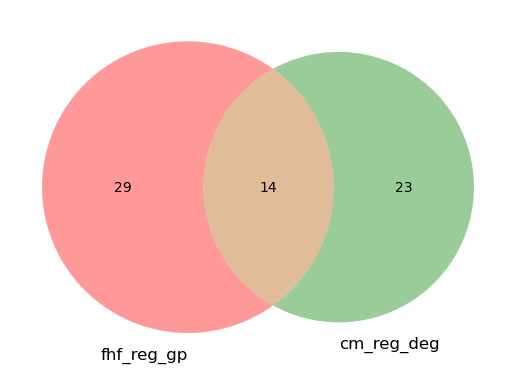

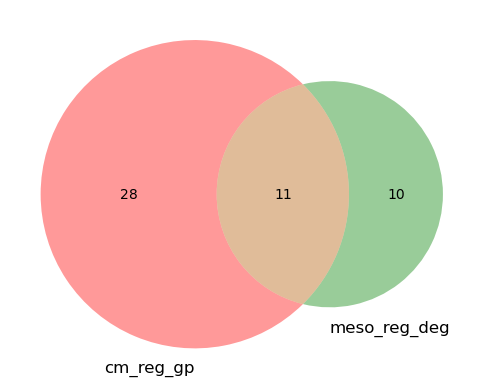

In [13]:
for gene_list_1,gene_list_2 in compare_set:
    venn2(subsets=(dataset[gene_list_1], dataset[gene_list_2]),
          set_labels=(gene_list_1, gene_list_2))
    plt.savefig(f"../figure/venn_{gene_list_1}_{gene_list_2}.pdf")
    plt.show()